In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import pandas as pd

In [29]:
sns.set_theme(font_scale=1)
sns.set_style("whitegrid")


In [5]:
ls

2026-03-16_longplex-results.ipynb  2026-04-03_hifi.ipynb
2026-03-17_longplex_success.ipynb  PB_cost-analysis.ipynb
2026-03-18_mastermix-bias.ipynb


In [7]:
# read in file and skip first row which is the SuppTable1... info
df=pd.read_csv('../Supplemental_Tables/Supp_Table_1_HiFi-metagenomics.csv', skiprows=1)

In [10]:
df.head()

,Paper_ID,include_newdata,First_Author,Year,Full_Citation,DOI,Journal,Sample_Type,Environment,DNA_Shearing_Method,...,Assembler_Used,Era_Classification,Access_Status,Notes,Article_Type,New_Data,True_HiFi,EMPO_1,EMPO_2,EMPO_3
0,1,1,Beinart,2026,"Beinart R, Breusing C, Oatley G, Sinclair E, A...",10.12688/wellcomeopenres.25894.1,Wellcome Open Research,Deep-sea hydrothermal vent gastropod snail (Al...,Deep-sea hydrothermal vent (Tu'i Malila vent f...,Megaruptor 3; PowerMasher II tissue disruptor ...,...,MetaMDBG (metagenome),TRUE HiFi,Open Access,ASG (Aquatic Symbiosis Genomics) + Sanger Tree...,Research,True,True,Host-associated,Animal,Animal corpus
1,2,1,Cárdenas,2026,"Cárdenas P, Busch K, Erpenbeck D, Hentschel U,...",10.12688/wellcomeopenres.25960.1,Wellcome Open Research,Arctic deep-sea HMA demosponge (Geodia parva H...,"Deep-sea Arctic seamount (Schulz Bank, 73.7702...",Megaruptor 3; sponge squeezing tissue disrupti...,...,MetaMDBG (metagenome),TRUE HiFi,Open Access,ASG (Aquatic Symbiosis Genomics) + Sanger Tree...,Research,True,True,Host-associated,Animal,Animal corpus
2,3,1,Cárdenas,2026,"Cárdenas P, Busch K, Erpenbeck D, Hentschel U,...",10.12688/wellcomeopenres.25984.1,Wellcome Open Research,Boreal North Atlantic HMA demosponge (Geodia p...,"Boreal deep-sea reef (Sula Reef, 71.5897°N, 21...",Megaruptor 3; sponge squeezing tissue disrupti...,...,MetaMDBG (metagenome),TRUE HiFi,Open Access,ASG (Aquatic Symbiosis Genomics) + Sanger Tree...,Research,True,True,Host-associated,Animal,Animal corpus
3,4,0,Chen,2026,"Chen K, Luo S, Jiang C, Gu S, Yang F, Liu X, W...",10.1111/1755-0998.70092,Molecular Ecology Resources,NaN,NaN,NaN,...,NaN,TOOL/REVIEW,Open Access,Tool paper introducing HiMBar (High-Fidelity M...,Methods,True,False,NaN,NaN,NaN
4,5,1,Chin,2026,"Chin D, Campbell B, Petersen J, Lim SJ, Oatley...",10.12688/wellcomeopenres.25920.1,Wellcome Open Research,Buttercup lucine bivalve (Anodontia alba; Moll...,"Seagrass sediments (Sammy Creek Landing, FL, U...",Megaruptor 3; PowerMasher II tissue disruptor ...,...,MetaMDBG (metagenome); Hifiasm v0.19.8-r603 (e...,TRUE HiFi,Open Access,ASG (Aquatic Symbiosis Genomics) + Sanger Tree...,Research,True,True,Host-associated,Animal,Animal corpus


In [15]:
# subset the full HiFi dataset to only include datasets which have new HiFi data and are research articles... 111 total studies
df111=df.loc[df["include_newdata"]==1]

In [17]:
df111.shape

(111, 30)

In [19]:
all_empo3 = [
    'Water (non-saline)', 'Sediment (non-saline)', 'Soil (non-saline)',
    'Surface (non-saline)', 'Subsurface (non-saline)', 'Aerosol (non-saline)',
    'Water (saline)', 'Sediment (saline)', 'Hypersaline (saline)',
    'Surface (saline)', 'Aerosol (saline)',
    'Animal distal gut', 'Animal proximal gut', 'Animal secretion',
    'Animal surface', 'Animal corpus',
    'Plant secretion', 'Plant surface', 'Plant rhizosphere', 'Plant corpus',
    'Fungus corpus', 'Fungus surface',
]

empo3_to_empo2 = {
    'Water (non-saline)': 'Non-saline', 'Sediment (non-saline)': 'Non-saline',
    'Soil (non-saline)': 'Non-saline', 'Surface (non-saline)': 'Non-saline',
    'Subsurface (non-saline)': 'Non-saline', 'Aerosol (non-saline)': 'Non-saline',
    'Water (saline)': 'Saline', 'Sediment (saline)': 'Saline',
    'Hypersaline (saline)': 'Saline', 'Surface (saline)': 'Saline',
    'Aerosol (saline)': 'Saline',
    'Animal distal gut': 'Animal', 'Animal proximal gut': 'Animal',
    'Animal secretion': 'Animal', 'Animal surface': 'Animal',
    'Animal corpus': 'Animal',
    'Plant secretion': 'Plant', 'Plant surface': 'Plant',
    'Plant rhizosphere': 'Plant', 'Plant corpus': 'Plant',
    'Fungus corpus': 'Fungus', 'Fungus surface': 'Fungus',
}

empo2_colors = {
    'Non-saline': '#4C9BE8',
    'Saline':     '#1A5276',
    'Animal':     '#E67E22',
    'Plant':      '#27AE60',
    'Fungus':     '#8E44AD',
}

empo_counts = (df111['EMPO_3']
               .dropna()
               .value_counts()
               .reindex(all_empo3, fill_value=0))

In [20]:
print(empo_counts)

EMPO_3
Water (non-saline)         18
Sediment (non-saline)       3
Soil (non-saline)           7
Surface (non-saline)        2
Subsurface (non-saline)     0
Aerosol (non-saline)        0
Water (saline)             14
Sediment (saline)           3
Hypersaline (saline)        0
Surface (saline)            1
Aerosol (saline)            0
Animal distal gut          11
Animal proximal gut         3
Animal secretion            0
Animal surface              0
Animal corpus              40
Plant secretion             0
Plant surface               0
Plant rhizosphere           0
Plant corpus                4
Fungus corpus               4
Fungus surface              0
Name: count, dtype: int64


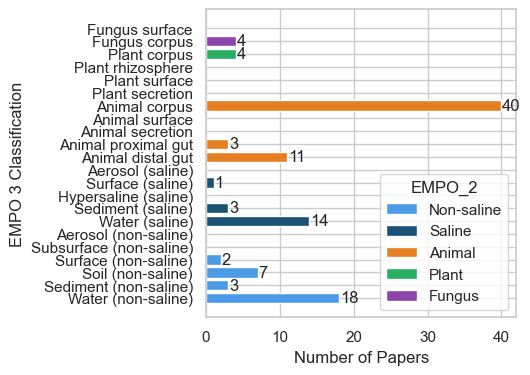

In [31]:
#plt.figure(figsize=(4,4))

bar_colors = [empo2_colors[empo3_to_empo2[e3]] for e3 in empo_counts.index]

fig, ax = plt.subplots(figsize=(4, 4))
ax.barh(range(len(empo_counts)), empo_counts.values, color=bar_colors)
ax.set_yticks(range(len(empo_counts)))
ax.set_yticklabels(empo_counts.index)

ax.set_ylabel('EMPO 3 Classification')
ax.set_xlabel('Number of Papers')
#ax.set_title('HiFi Metagenomics Papers by EMPO_3 Classification')

for i, v in enumerate(empo_counts):
    if v > 0:
        ax.text(v + 0.1, i, str(v), va='center')

legend_elements = [Patch(facecolor=color, label=empo2)
                   for empo2, color in empo2_colors.items()]
ax.legend(handles=legend_elements, title='EMPO_2', loc='lower right')

#plt.tight_layout()
plt.savefig("../Figures/Fig2C_EMP.png", dpi=300, bbox_inches='tight')
plt.show()
